# 02. Cloudrunner Single Tile Processing Guide

This notebook demonstrates how to set up and test the cloudrunner toolset for LiDAR processing.


## 0. SETUP


### Import Python Libraries

In [56]:
import pdal
import geopandas as gpd
import matplotlib.pyplot as plt

### Working Directory

In [57]:
# set the base working directory

wd = "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial"

# set up a few variables to edit
zmin = 245
zmax = 280
attribute_name = "Buffer"

### Project Variables

If that is set correctly, then the following subdirectories relative to the ```wd``` should not need to be edited.

In [58]:
# this can be left alone

# Create directory variables
lidar_dir  = f"{wd}/data/test"
raster_dir = f"{wd}/data/tif"
shapes_dir = f"{wd}/data/shp"

# Create file name variables
# ---------------------------
# lidar
las_name  = "ARS_Aspens_08242020_grid_lidar"
base_las  = f"{lidar_dir}/{las_name}"
las_file  = f"{base_las}.las"

# shapes
polyname = "aspens-comp-garden_buffer_poly"
polygon_file = f"{shapes_dir}/{polyname}.geojson"

# raster
rgb_file  = f"{raster_dir}/ARLINGTON-ARS_20200824_02_Refl_rgb_clip.tif"
swir_file = f"{raster_dir}/ARLINGTON-ARS_20200824_02_Refl_swir_clip.tif"

Use `pdal info` to look at the file properties.

The ` --metadata` flag will run faster and only grab the header information.

In [59]:
!pdal info {las_file} --metadata

{
  "file_size": 1023010736,
  "filename": "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/test/ARS_Aspens_08242020_grid_lidar.las",
  "metadata":
  {
    "comp_spatialreference": "PROJCS[\"WGS 84 / UTM zone 16N\",GEOGCS[\"WGS 84\",DATUM[\"WGS_1984\",SPHEROID[\"WGS 84\",6378137,298.257223563,AUTHORITY[\"EPSG\",\"7030\"]],AUTHORITY[\"EPSG\",\"6326\"]],PRIMEM[\"Greenwich\",0,AUTHORITY[\"EPSG\",\"8901\"]],UNIT[\"degree\",0.0174532925199433,AUTHORITY[\"EPSG\",\"9122\"]],AUTHORITY[\"EPSG\",\"4326\"]],PROJECTION[\"Transverse_Mercator\"],PARAMETER[\"latitude_of_origin\",0],PARAMETER[\"central_meridian\",-87],PARAMETER[\"scale_factor\",0.9996],PARAMETER[\"false_easting\",500000],PARAMETER[\"false_northing\",0],UNIT[\"metre\",1,AUTHORITY[\"EPSG\",\"9001\"]],AXIS[\"Easting\",EAST],AXIS[\"Northing\",NORTH],AUTHORITY[\"EPSG\",\"32616\"]]",
    "compressed": false,
    "copc": false,
    "count": 36536082,
    "creation_doy": 238,
    "creation_year": 2020,
    "dataformat_id": 1,
    "data

The main function will return the cloud stats and attribute information.

In [61]:
%%time
!pdal info {las_file}

{
  "file_size": 1023010736,
  "filename": "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/test/ARS_Aspens_08242020_grid_lidar.las",
  "now": "2025-04-29T10:21:53-0500",
  "pdal_version": "2.8.4 (git-version: 412c57)",
  "reader": "readers.las",
  "stats":
  {
    "bbox":
    {
      "EPSG:4326":
      {
        "bbox":
        {
          "maxx": -89.36379011,
          "maxy": 43.29089448,
          "maxz": 397.873,
          "minx": -89.36763761,
          "miny": 43.28814034,
          "minz": 229.644
        },
        "boundary": { "type": "Polygon", "coordinates": [ [ [ -89.367533726317546, 43.288140337127032, 229.644 ], [ -89.367637606285911, 43.290817005394466, 229.644 ], [ -89.363893821666039, 43.29089447883959, 397.873 ], [ -89.363790105582751, 43.28821780336947, 397.873 ], [ -89.367533726317546, 43.288140337127032, 229.644 ] ] ] }
      },
      "native":
      {
        "bbox":
        {
          "maxx": 308231.014,
          "maxy": 4795832.379,
          "maxz":

## 1. Create Functions

Functions for plotting that are not present in the code base. These can help reduce code overhead for repetitive tasks.

In [ ]:
# Custom functions

# Create Rasterio function to read raster
def rio_read(file,bands=[1,2,3]):
    import rasterio
    with rasterio.open(file) as src:
        raster = src.read(bands) # Read the red, green, and blue bands
        transform = src.transform
        return raster, transform


# Create a function for plotting the point cloud
def plot_cloud(arrays, zlims=[0,25], zlabel = "Height Above Ground", point_thresh=500000, mark='.', cmap='jet', fig_size=(8,8), pt_alpha=.7):
    fig = plt.figure(figsize=fig_size)
    ax = fig.add_subplot(111, projection='3d')

    # - Access the x, y, z points as numpy arrays
    # - use point threshold to limit the number of points plotted
    x = arrays['X'][:point_thresh]
    y = arrays['Y'][:point_thresh]
    z = arrays['Z'][:point_thresh]

    # - Create the scatter plot, coloring by z value
    scatter = ax.scatter(x, y, z, c=z, cmap=cmap, marker=mark, alpha=pt_alpha)

    # - Add a colorbar
    cbar = fig.colorbar(scatter)

    # - Set the colorbar label
    cbar.set_label('Height Above Ground (m)', fontsize=10)

    # - Set labels for the axes
    ax.set_xlabel('X - Northing (m)')
    ax.set_ylabel('Y - Easting (m)')
    ax.set_zlabel(f'Z - {zlabel}  (m)', fontsize=9)
    ax.set_title("Lidar Point Cloud", fontsize=12)

    # - Set height Z-axis limits
    ax.set_zlim(zlims[0], zlims[1])

    # - Show the plot with tight layout
    plt.tight_layout()
    plt.show()

    return fig, ax

## 2. Support Shapes

Vector files can be used to clip point clouds.

There is a single attribute of "Buffer" where the outer Buffer = 1 and the main tile is Buffer = 0.

,Buffer,geometry
0,0,"MULTIPOLYGON (((308087.633 4795704.687, 308089..."
1,1,"MULTIPOLYGON (((308036.301 4795704.244, 308037..."


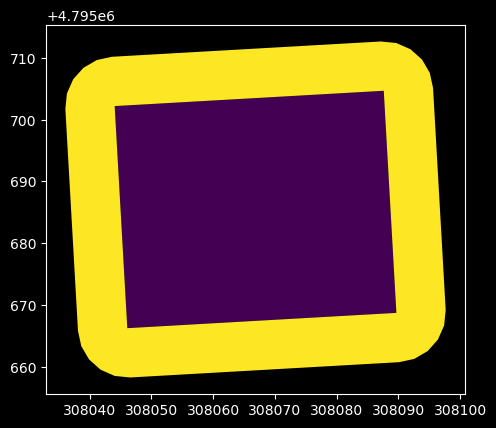

In [ ]:
polygon = gpd.read_file(polygon_file)

polygon.plot(column="Buffer")

polygon

### Tile Poly

<Axes: >

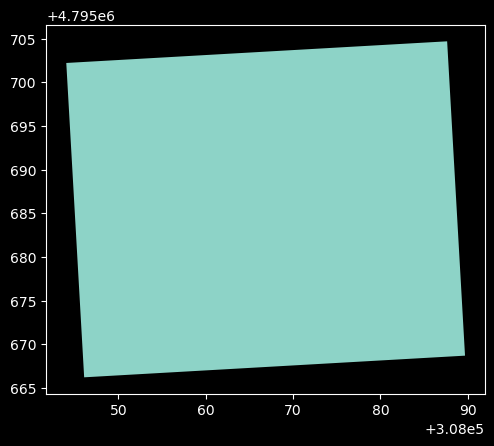

In [ ]:
tile_polygon = polygon[polygon.loc[:,"Buffer"] == 0 ]
tile_polygon.plot()

### Save wkt for later

In [ ]:
# get the WKT for the crop filters
polygon_wkt     = polygon.union_all().wkt
tile_wkt        = tile_polygon.union_all().wkt

print(polygon_wkt)
print(tile_wkt)

POLYGON ((308037.30905160075 4795706.534768059, 308038.97555741586 4795708.402259501, 308041.1375852229 4795709.663370786, 308043.5835006764 4795710.194655558, 308087.178826519 4795712.674010582, 308089.6692063727 4795712.423462984, 308091.9602748949 4795711.415608361, 308093.827766336 4795709.749102547, 308095.088877622 4795707.587074739, 308095.6201623936 4795705.141159286, 308097.66650932375 4795669.159559097, 308097.4159617259 4795666.669179244, 308096.40810710314 4795664.378110722, 308094.741601288 4795662.51061928, 308092.579573481 4795661.249507994, 308090.1336580275 4795660.7182232225, 308046.5383321849 4795658.238868198, 308044.0479523312 4795658.4894157965, 308041.756883809 4795659.497270419, 308039.8893923679 4795661.163776234, 308038.6282810819 4795663.325804042, 308038.0969963103 4795665.771719495, 308036.05064938014 4795701.7533196835, 308036.30119697796 4795704.243699537, 308037.30905160075 4795706.534768059))
POLYGON ((308087.6330688082 4795704.686916997, 308089.6794157

## 3. CLIP Pipeline

We will start with a simple clipping pipeline to reduce the file size. At this stage, we will still retain a beffered area around the target area to ensure edge errors don't propagate.

### Initialize

Create an empty pipeline object.

In [64]:
clip_pipeline = pdal.Pipeline()

### Reader

The reader for PDAL simply needs a filename. More args are available on [PDAL's docs](https://pdal.io/en/stable/index.html).


In [ ]:
reader = pdal.Reader.las(filename=las_file)

### Ferry

The ferry filter can change existing or create a new attribute.

Two main ways to use the `=>` operand:
 - duplicate existing attribute : `Z=>Z_UTM` 
 - create empty new attribute   : `=>Buffer`

Since the Buffer attribute doesn't already exist in the point cloud, it needs to be added using the second option.

In [66]:
ferry = pdal.Filter.ferry(dimensions=f"=>{attribute_name}")

### Overlay

In [67]:
overlay = pdal.Filter.overlay(datasource=polygon_file,
                              dimension=attribute_name,
                              column=attribute_name)

### Crop

Now we can create the crop filter.

In [68]:
crop = pdal.Filter.crop(polygon=polygon_wkt)

### Writer

Create a writer to output the smaller tile.

In [69]:
writer = pdal.Writer.las(filename=f"{base_las}_c.las",
                         minor_version="4",
                         dataformat_id="8",
                         scale_z=1.0,
                         extra_dims="all",
                         forward="all")

### Build Pipeline from Stages

Now that the stages are all defined, they can be used to create the total pipeline.

Using the `|= ` operand appends stages to the pipeline.

In [70]:
clip_pipeline |= reader | ferry | overlay | crop | writer

### Execute the Pipeline

In [71]:
%%time
clip_pipeline.execute()
clip_arrays = clip_pipeline.arrays[0]

CPU times: user 13.1 s, sys: 1.41 s, total: 14.5 s
Wall time: 14.4 s


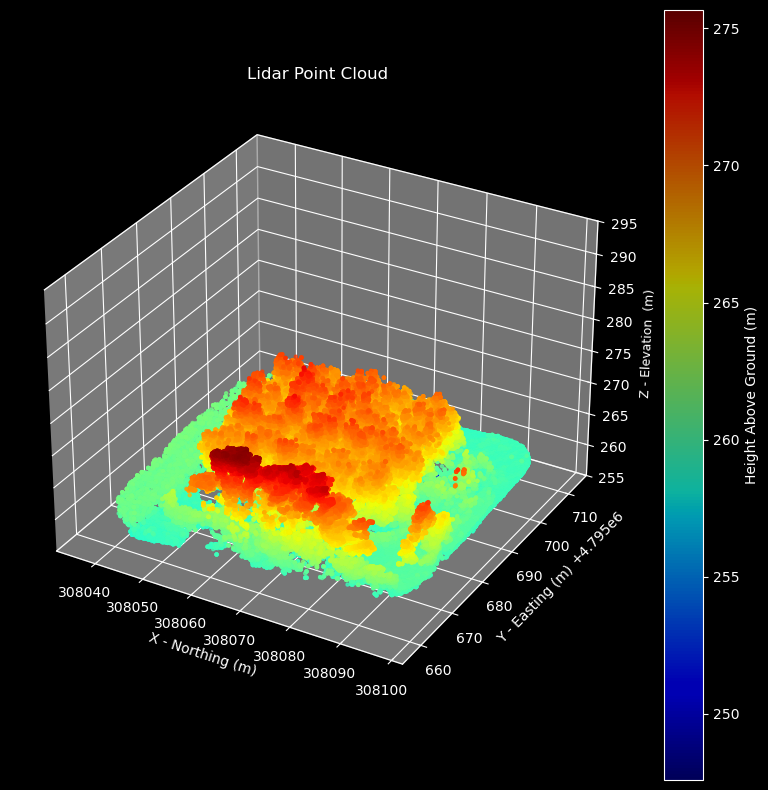

In [72]:
fig,ax = plot_cloud(clip_arrays, zlims=[255,295], zlabel = "Elevation")

## 4. PROCESS Pipeline

For the process pipeline, we will put it all in one cell.

Let's first outline what the pipeline will accomplish.

Steps for the pipeline:
1. Read
1. Clean 
    1. Outliers      - classified with a value of 7
    1. Zlim range    - drop values below `zmin` and above `zmax`
1. Classify Ground   - find ground values
1. Normalize         - calculate height above ground
1. Change Z          - move Z values with elevation to Z_UTM
1. Crop              - remove the buffered area
1. Filter            - remove negative values
1. Write
    1. Las Tile
    1. COPC Tile

> Range Filtering : A very simple way to get rid of outliers is to use a known range to threshold the cloud and drop anything above and below it. It is *critical* to note that at this stage the Z values still represent elevation above sea level (in meters), so the limits should be set accordingly.
>
>With drone fligths, the values can be determined easily while the copter is flying and noted for later use. If not known precisely, these can be estimated using plotting methods shown above with `zlims`.

### Stages

In [ ]:
proc_pipeline = pdal.Pipeline()

# 1 - READER
preader = pdal.Reader.las(filename=f"{base_las}_c.las")

# 2 - OUTLIER IDENTIFICATION
#outlier = pdal.Filter.outlier(method="statistical", multiplier=2, mean_k=20)
outlier = pdal.Filter.outlier(method="radius")

#   - OUTLIER REMOVAL
outlier_rng = pdal.Filter.expression(expression=f"(Classification != 7) && (Z >= {zmin} && Z <= {zmax})")

# 3 - GROUND CLASSIFICATION
ground = pdal.Filter.csf(resolution=2.0,returns="first, last,intermediate,only")

# 4 - HAG --> Height Above Ground
hag = pdal.Filter.hag_delaunay(count=25)

# 5 - ALTER Z values to HeightAboveGround
changeZ = pdal.Filter.ferry(dimensions="Z => Z_UTM, HeightAboveGround => Z")

# 6 - CROP BUFFER to TILE
pcrop = pdal.Filter.crop(polygon=tile_wkt)

# 7 - Filter negatives to zero
zero = pdal.Filter.assign(value="Z = 0. WHERE Z < 0.")

# 8 - WRITE OUTPUT
copc = pdal.Writer.copc(f"{base_las}_cgn-NEW.copc.laz", forward="all", extra_dims="all", threads=1)
pwriter = pdal.Writer.las(f"{base_las}_cgn-NEW.las", minor_version="4", dataformat_id="8", scale_z=1.0, extra_dims="all", forward="all")


### Build Pipeline

In [ ]:
# NOTE : writer includes buffer, copc is after crop stage and has buffer removed

proc_pipeline |= preader | outlier | outlier_rng | ground | hag | changeZ | zero | pwriter | pcrop | copc

### Execute Processing Pipeline

In [ ]:
%%time

proc_pipeline.execute()
proc_arrays = proc_pipeline.arrays[0]


CPU times: user 28min 42s, sys: 1.71 s, total: 28min 44s
Wall time: 28min 49s


#### Plot Normalized Point Cloud

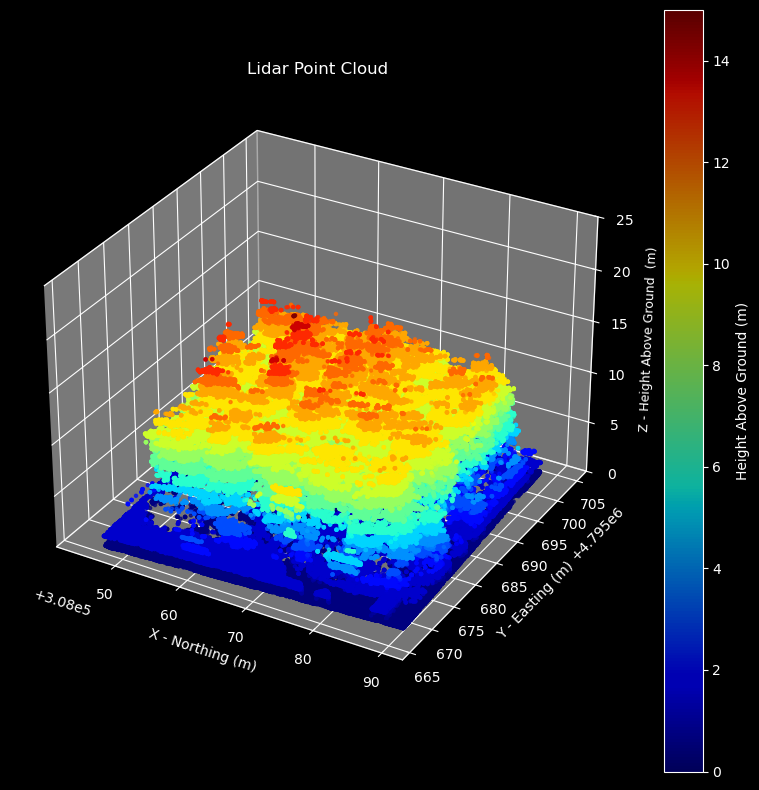

In [ ]:
fig,ax = plot_cloud(proc_arrays)

#### Check Metadata

A quick look at the output cloud metadata can show if values (zmin and zmax) and attributes (Classification) appear correct.

In [ ]:
temp_las = f"{base_las}_cgn-NEW.las"
!pdal info {temp_las} --metadata

{
  "file_size": 236138983,
  "filename": "/mnt/farnsworth/Enspec/users/whills/PDAL_tutorial/data/test/ARS_Aspens_08242020_grid_lidar_cgn-NEW.las",
  "metadata":
  {
    "comp_spatialreference": "PROJCS[\"WGS 84 / UTM zone 16N\",GEOGCS[\"WGS 84\",DATUM[\"WGS_1984\",SPHEROID[\"WGS 84\",6378137,298.257223563,AUTHORITY[\"EPSG\",\"7030\"]],AUTHORITY[\"EPSG\",\"6326\"]],PRIMEM[\"Greenwich\",0,AUTHORITY[\"EPSG\",\"8901\"]],UNIT[\"degree\",0.0174532925199433,AUTHORITY[\"EPSG\",\"9122\"]],AUTHORITY[\"EPSG\",\"4326\"]],PROJECTION[\"Transverse_Mercator\"],PARAMETER[\"latitude_of_origin\",0],PARAMETER[\"central_meridian\",-87],PARAMETER[\"scale_factor\",0.9996],PARAMETER[\"false_easting\",500000],PARAMETER[\"false_northing\",0],UNIT[\"metre\",1,AUTHORITY[\"EPSG\",\"9001\"]],AXIS[\"Easting\",EAST],AXIS[\"Northing\",NORTH],AUTHORITY[\"EPSG\",\"32616\"]]",
    "compressed": false,
    "copc": false,
    "count": 3808656,
    "creation_doy": 238,
    "creation_year": 2020,
    "dataformat_id": 8,
   

This can also be done within jupyter cell if you still have the object available.

In [ ]:
proc_pipeline.metadata

{'metadata': {'filters.assign': {},
  'filters.crop': {},
  'filters.csf': {},
  'filters.expression': {},
  'filters.ferry': {},
  'filters.hag_delaunay': {},
  'filters.outlier': {},
  'readers.las': {'comp_spatialreference': 'PROJCS["WGS 84 / UTM zone 16N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-87],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32616"]]',
   'compressed': False,
   'copc': False,
   'count': 3808736,
   'creation_doy': 238,
   'creation_year': 2020,
   'dataformat_id': 8,
   'dataoffset': 1927,
   'filesou

## Summary & Next Steps

The tutorials have covered:
1. Steps for processing a high density, raw point cloud
    1. Reading tiles
    1. Clipping
    1. Buffering (Ferry & Overlay)
    1. Cleaning
    1. Ground Classification
    1. Height normalization
    1. Point Colorization
    1. Writing tiles to LAZ/LAS and COPC

 


   
2. Two ways to run pipelines built with stages
  
    A. Pure python inside scripts or jupyter cells
  
    ```
    proc_pipeline |= reader | outlier | ground | hag | changeZ | crop | writer
    ```
  
    B. JSON files with stages stacked in order
  
    ```
    [
    {
        "type": "readers.las",
        "filename": "/path/to/lidar.las"
    },
    {
        "type": "filters.colorization",
        "raster": "/path/to/raster.tif"
    },
    {
        "type": "writers.las",
        "filename": "/path/to/lidar_colors.las",
        "minor_version": "4",
        "dataformat_id": "8",
        "scale_z": "1.0",
        "extra_dims": "all",
        "forward": "all"
    }
    ]
    ```
      


This is the end of this notebook. Please proceed to the next notebook for Multiple Tile Processing.